#1.Categories

##1.1.Importing File

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# products_cl.csv
url = "https://drive.google.com/file/d/138bHAL4GZNfW7Ro0smVv9IcaOBVy7dhf/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)


# orders_cl.csv
url = "https://drive.google.com/file/d/1VzYlJhyImkD3JVUuNPf66ycrrugINAA3/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1VUFfDkoJP1slgm645ycA_-KIGySmx2Fd/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)


In [ ]:
product_category_df = products_cl.copy()
orders_qa = orders_cl.copy()
orderlines_qa = orderlines_cl.copy()

##1.2.Defining display

In [ ]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)
pd.set_option("display.max_rows", 1000)

##1.3 Discount Categories

 Exercise 1: Create a new column in the orderlines data frame called `'revenue'` by multiplying quantity by unit price

In [ ]:
#there are revenue,month,period_quarter,unit_price_total,unit_price_quantity,is_free_item
orderlines_qu.sample(10)

NameError: name 'orderlines_qu' is not defined

Exercise 2: Incorporate the total revenue for each order into the orders data frame

##1.4.Product Categories

###1.4.1.Observation

In [ ]:
product_category_df.head()

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364


In [ ]:
#create new column
product_category_df["category"] = ""
product_category_df.head()

,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,


In [ ]:
#finding the most frquent words
#splitting name string to seperated words
all_words = ' '.join(product_category_df['name'].astype(str)).lower().split()
#searching in separated word
word_counts = pd.Series(all_words).value_counts()
print(word_counts.head(100))

|              3893
apple          2618
iphone         1956
case           1947
/              1921
pro            1764
-              1480
black          1264
macbook        1221
ram            1209
ssd            1062
open            964
+               958
ipad            864
mac             820
plus            813
usb             805
"core           795
and             737
16gb            727
6               708
imac            690
retina          682
nas             648
8gb             636
gray            636
synology        615
2               588
6s              587
13              565
1tb             515
wd              507
27              502
server          501
mini            497
white           481
seagate         476
pack            475
air             474
i5              474
drive           453
3.0             451
silver          430
space           415
owc             408
red             397
7               396
for             390
kit             388
hard            380


In [ ]:
#finding the most frequent words
#splitting name string to separated words
all_words = product_category_df['name'].str.cat(sep=' ').lower().split()
# filtering: deleting lower than 2 character
filtered_words = [word for word in all_words if len(word) > 2]
# counting
word_counts = pd.Series(filtered_words).value_counts()
print(word_counts.head(100))

apple          2618
iphone         1956
case           1947
pro            1764
black          1264
macbook        1221
ram            1209
ssd            1062
open            964
ipad            864
mac             820
plus            813
usb             805
"core           795
and             737
16gb            727
imac            690
retina          682
nas             648
8gb             636
gray            636
synology        615
1tb             515
server          501
mini            497
white           481
seagate         476
pack            475
air             474
drive           453
3.0             451
silver          430
space           415
owc             408
red             397
for             390
kit             388
hard            380
blue            374
qnap            373
gold            359
new             355
32gb            343
256gb           341
like            340
thunderbolt     333
flash           323
watch           313
memory          302
4gb             296


In [ ]:
#finding the most frequent words
#splitting desc string to separated words
all_words = product_category_df['desc'].str.cat(sep=' ').lower().split()
# filtering: deleting lower than 2 character
filtered_words = [word for word in all_words if len(word) > 2]
# counting
word_counts = pd.Series(filtered_words).value_counts()
print(word_counts.head(100))

and              6802
for              5409
with             3269
iphone           2791
mac              2467
ram              1633
ipad             1528
pro              1473
macbook          1450
ssd               980
hard              964
apple             936
case              918
usb               918
inch              905
nas               857
imac              838
drive             805
retina            800
16gb              682
plus              653
8gb               609
new               608
cover             566
pc.               521
core              514
mini              500
ipod              481
external          467
server            457
3.0               451
1tb               450
air               436
desktop           411
touch             375
connection        370
memory            370
computer          361
thunderbolt       359
bluetooth         358
a).               356
cable             354
watch             351
inches            347
kit               343
the       

In [ ]:
product_category_df['type'].unique()

array(['8696', '13855401', '1387', '1230', '1364', '1325', '5384', '1334',
       '13005399', '13835403', '12995397', '11865403', '13955395', '1216',
       '12355400', '5,49E+11', '1276', '11905404', '12635403', '12755395',
       '1296', '12285400', '1229', '11935397', '12655397', '1404',
       '101781405', '4259', '14035403', '12085400', '1282', '12175397',
       '1424', '9094', '1405', '57445397', nan, '14305406', '10142',
       '12645406', '10230', '12215397', '11821715', '13555403',
       '14365395', '1,44E+11', '5405', '5395', '5398', '21485407',
       '20642062', '1280', '12575403', '1433', '1515', '5720', '1298',
       '13615399', '12585395', '1392', '1231', '15435404', '1375',
       '42945397', '12141714', '54025401', '21535407', '1416', '2,17E+11',
       '24215399', '11434', '2425', '2434', '2449', '13621714',
       '24861714', '24821716', '5,74E+15', '54864259', '51861714', '1714',
       '51601716', '51871714', '5403', '54085407', '24885185', '24895185',
       '5

In [ ]:
product_category_df.groupby("type").count().nlargest(20, "sku")

,sku,name,desc,price,in_stock,category
type,,,,,,
11865403,1057,1057,1057,1057,1057,1057
12175397,939,939,939,939,939,939
1298,783,783,783,783,783,783
11935397,562,562,562,562,562,562
11905404,454,454,454,454,454,454
1282,373,373,373,373,373,373
12635403,362,362,362,362,362,362
13835403,269,269,269,269,269,269
"5,74E+15",247,247,247,247,247,247


In [ ]:
product_category_df.groupby('type')['name'].count()

,name
type,
"1,02E+12",130
"1,44E+11",129
10142,23
101781405,10
10230,29
106431714,29
113271716,4
113281716,16
113291716,13


In [ ]:
product_category_df.groupby(['type', 'name']).size()

type      name                                                                       
1,02E+12  Apple MacBook Pro 13 "Core i5 2.3GHz | 16GB | 256GB SSD Space Gray             1
          Apple MacBook Pro 13 "Core i5 23GHz | 8GB RAM | 128GB PCIe SSD | Silver        1
          Apple MacBook Pro 13 "Core i5 23GHz | 8GB RAM | 128GB PCIe SSD | Space Gray    1
          Apple MacBook Pro 13 "Core i5 23GHz | 8GB RAM | 256GB PCIe SSD | Silver        1
          Apple MacBook Pro 13 "Core i5 23GHz | 8GB RAM | 256GB PCIe SSD | Space Gray    1
                                                                                        ..
9094      Spotlight Ring Cabling White Wired CCTV camera                                 1
          Video surveillance camera Floodlight Ring with Black Spots                     1
          Video surveillance camera Floodlight Ring with White Spotlights                1
          Welcome Netatmo facial recognition camera                                      1
          Withings Home HD camera                                                        1
Length: 9815, dtype: int64

In [ ]:
product_category_df.groupby('type')['name'].value_counts()

type      name                                                                                                                
1,02E+12  Like new - Apple MacBook Pro 15 "Core i7 Touch Bar 27GHz | RAM 16GB | 512GB PCIe SSD | 455 2GB Radeon Pro Space Gray    2
          Apple MacBook Pro 13 "Core i5 2.3GHz | 16GB | 256GB SSD Space Gray                                                      1
          Apple MacBook Pro 13 "Core i5 23GHz | 8GB RAM | 128GB PCIe SSD | Silver                                                 1
          Apple MacBook Pro 13 "Core i5 23GHz | 8GB RAM | 128GB PCIe SSD | Space Gray                                             1
          Apple MacBook Pro 13 "Core i5 23GHz | 8GB RAM | 256GB PCIe SSD | Silver                                                 1
                                                                                                                                 ..
9094      Spotlight Ring Cabling White Wired CCTV camera                                                                          1
          Video surveillance camera Floodlight Ring with Black Spots                                                              1
          Video surveillance camera Floodlight Ring with White Spotlights                                                         1
          Welcome Netatmo facial recognition camera                                                                               1
          Withings Home HD camera                                                                                                 1
Name: count, Length: 9815, dtype: int64

In [ ]:
product_category_df['name'].isna().sum()

np.int64(0)

In [ ]:
product_category_df['type'].isna().sum()

np.int64(46)

In [ ]:
n = 30
print(f"With the {n} largest types, we account for {((product_category_df.groupby('type').count().nlargest(n, 'sku')['sku'].sum()) / (product_category_df.shape[0]) * 100).round(2)}% of all products.")

With the 30 largest types, we account for 78.4% of all products.


###1.4.2.Creating Category list



In [ ]:
from google.colab import files
#loop for printing every unique type
for type_val in product_category_df['type'].unique():
    print(f"\n=== Type: {type_val} ===")
    #print type in product_category_df
    group = product_category_df[product_category_df['type'] == type_val]
    #counting most frequent words in name
    all_words = group['name'].str.cat(sep=' ').lower().split()
    filtered_words = [word for word in all_words if len(word) > 2]
    word_counts = pd.Series(filtered_words).value_counts()
    print(word_counts)

Streaming output truncated to the last 5000 lines.
pegasus            3
40tb               3
adapter            3
cloudbox           3
18tb               3
morado             3
quad               3
hub                3
8big               3
wifi               3
orange             3
rack               3
(4x12tb)           2
(4x6tb)            2
(4x10tb)           2
purple             2
san                2
marvel             2
(4x8tb)            2
(4x2tb)            2
(4x3tb)            2
(4x4tb)            2
2010/2011          2
evo                2
g-dock             2
pen-drive-c        2
like               2
with               2
60tb               2
64tb               2
"fw800             2
72tb               2
96tb               2
transparent        2
retina             2
extraible          2
fuel               2
sdxc               2
dial               2
5-bay              2
p20                2
jumpdrive          2
sdhc               2
uhs-i              2
array              2
bays

In [ ]:
from google.colab import files

# a list to save all output
all_results = []

#loop for printing every unique type
for type_val in product_category_df['type'].unique():
    print(f"\n=== Type: {type_val} ===")

    #filter type in product_category_df
    group = product_category_df[product_category_df['type'] == type_val]

    #counting most frequent words in name
    all_words = group['name'].str.cat(sep=' ').lower().split()
    filtered_words = [word for word in all_words if len(word) > 2]

    #counting
    word_counts = pd.Series(filtered_words).value_counts()

    #convert to DataFrame
    word_df = word_counts.reset_index()
    word_df.columns = ['word', 'count']

    #add type column
    word_df['type'] = type_val

    #add to list
    all_results.append(word_df)

#combine all DataFrames
final_df = pd.concat(all_results, ignore_index=True)

#save to csv
final_df.to_csv('all_word_counts_by_type.csv', index=False)

#download
files.download("all_word_counts_by_type.csv")

print(f"Saved {len(final_df)} rows")


=== Type: 8696 ===

=== Type: 13855401 ===

=== Type: 1387 ===

=== Type: 1230 ===

=== Type: 1364 ===

=== Type: 1325 ===

=== Type: 5384 ===

=== Type: 1334 ===

=== Type: 13005399 ===

=== Type: 13835403 ===

=== Type: 12995397 ===

=== Type: 11865403 ===

=== Type: 13955395 ===

=== Type: 1216 ===

=== Type: 12355400 ===

=== Type: 5,49E+11 ===

=== Type: 1276 ===

=== Type: 11905404 ===

=== Type: 12635403 ===

=== Type: 12755395 ===

=== Type: 1296 ===

=== Type: 12285400 ===

=== Type: 1229 ===

=== Type: 11935397 ===

=== Type: 12655397 ===

=== Type: 1404 ===

=== Type: 101781405 ===

=== Type: 4259 ===

=== Type: 14035403 ===

=== Type: 12085400 ===

=== Type: 1282 ===

=== Type: 12175397 ===

=== Type: 1424 ===

=== Type: 9094 ===

=== Type: 1405 ===

=== Type: 57445397 ===

=== Type: nan ===

=== Type: 14305406 ===

=== Type: 10142 ===

=== Type: 12645406 ===

=== Type: 10230 ===

=== Type: 12215397 ===

=== Type: 11821715 ===

=== Type: 13555403 ===

=== Type: 14365395 ==

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved 9746 rows


In [ ]:
import pandas as pd

#reading the all_word_counts_by_type.csv
word_counts_by_type = pd.read_csv(
    'all_word_counts_by_type.csv',
    dtype={'type': 'string'}
)
# deleting unusefull words
stop_words = {
    'and', 'for', 'with', 'the', 'of', 'in',
    'to', 'from', 'new', 'black', 'white',
    'gray', 'grey', 'silver', 'blue', 'red',
    'gold', 'plus', 'pro'
}
filtered_words = word_counts_by_type[
    ~word_counts_by_type['word'].str.lower().isin(stop_words)
]
# sorting accordint to most ferquent words
filtered_words = filtered_words.sort_values(
    ['type', 'count'],
    ascending=[True, False]
)
# selecting 3 most frquent words per type
group_names = (
    filtered_words
    .groupby('type')
    .head(3)
    .groupby('type')['word']
    .apply(lambda words: ' '.join(words.str.title()))
    .reset_index(name='group_name')
)
#saving to csv file
group_names.to_csv('group_names_with_count.csv', index=False)
files.download("group_names_with_count.csv")
print(group_names.head(50))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

         type                 group_name
0    1,02E+12          Apple Macbook Ssd
1    1,44E+11         Repair Iphone Ipad
2       10142  Battery Macbook Newertech
3   101781405           Wacom Intuos Kit
4       10230      Macbook "Black Retina
5   106431714          Apple Ipad "Wi-Fi
6   113271716         Apple Iphone Space
7   113281716          Apple Iphone 64Gb
8   113291716          Apple Iphone 64Gb
9   113464259            Open 32Gb Apple
10  113851714           Apple Wi-Fi Ipad
11      11434        Apple Security Lock
12   11821715           Apple Ipod Touch
13      11859      Fibaro Sensor Homekit
14   11865403          Iphone Case Apple
15  118692158            Apple Imac Xeon
16   11905404         Iphone Ipad Parrot
17   11935397             Usb Hard Drive
18   12031714            Apple Ipad Mini
19   12051714             Air Ipad Wi-Fi
20   12085400       Spray Maclocks Stick
21   12141714           Apple Ipad Wi-Fi
22       1216      Ipad Support Security
23   12175397   

In [ ]:
#reading the group_name_with_count.csv
url = "https://drive.google.com/file/d/1rDDe_nDQM8JJRirSxp2dIxgQNPa9a1M9/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
group_names_with_count = pd.read_csv(path)
group_name_df = group_names_with_count.copy()

In [ ]:
#deletig dupplicated group_name
group_name_df['group_name'].duplicated().sum()

np.int64(13)

In [ ]:
#creating category_list
category_list = group_name_df['group_name'].drop_duplicates()
category_list

,group_name
0,Apple Macbook Ssd
1,Repair Iphone Ipad
2,Battery Macbook Newertech
3,Wacom Intuos Kit
4,"Macbook ""Black Retina"
5,"Apple Ipad ""Wi-Fi"
6,Apple Iphone Space
7,Apple Iphone 64Gb
9,Open 32Gb Apple
10,Apple Wi-Fi Ipad


In [ ]:
#checking most frequent words in category_list
group_names['main_category'] = group_names['group_name'].str.split().str[0]
print(group_names['main_category'].value_counts())

main_category
Apple           41
Iphone          10
Ifixit           5
Ipad             4
Keyboard         4
Macbook          3
Battery          3
Open             3
Second           3
Usb              2
Cable            2
Wacom            2
Mac              2
Like             2
Camera           2
Synology         1
Spray            1
Air              1
Repair           1
Fibaro           1
Gopro            1
Applecare        1
Belkin           1
Pointer          1
Ssd              1
Pcie             1
Owc              1
Drive            1
Charger          1
Memory           1
Microphones      1
Mouse            1
Backpack         1
Monitor          1
Thunderbolt      1
D-Link           1
External         1
Adobe            1
Qnap             1
Adapter          1
Installation     1
Screen           1
Lightning        1
Kit              1
Imac             1
Headphones       1
Speaker          1
Powercube        1
Wireless         1
Case             1
Card             1
Support          

In [ ]:
#manual mapping
merge_mapping = {
    'Apple Macbook Ssd': 'Mac Accessories',
    'Apple Ipad "Wi-Fi': 'iPad',
    'Apple Iphone Space': 'iPhone',
    'Apple Iphone 64Gb': 'iPhone',
    'Open 32Gb Apple': 'Apple Storage',
    'Apple Wi-Fi Ipad': 'iPad',
    'Apple Ipod Touch': 'iPod',
    'Iphone Case Apple': 'iPhone Cases',
    'Ipad Case Apple': 'iPad Cases',
    'Apple Ipad Mini': 'iPad Mini',
    'Apple Ipad Wi-Fi': 'iPad',
    'Apple Ipad Air': 'iPad Air',
    'Apple Ipad 12.9': 'iPad Pro',
    'Apple Ipad 9.7': 'iPad',
    'Apple Macbook "Core': 'MacBook',
    'Apple Macbook Ram': 'MacBook RAM',
    'Apple Macbook Air': 'MacBook Air',
    'Apple Macbook Pcie': 'MacBook PCIe',
    'Open Apple Macbook': 'MacBook',
    'Apple Mac Ssd': 'Mac SSD',
    'Apple Imac Xeon': 'iMac',
    'Apple Imac "Core': 'iMac',
    'Imac Apple Ram': 'iMac RAM',
    'Apple Mini Mac': 'Mac Mini',
    'Apple Watch 42Mm': 'Apple Watch',
    'Apple Watch 38Mm': 'Apple Watch',
    'Apple Watch 1St': 'Apple Watch',
    'Apple Watch Charging': 'Apple Watch',
    'Apple Strap 42Mm': 'Apple Watch',
    'Apple Iphone Like': 'iPhone',
    'Like Apple Iphone': 'iPhone',
    'Iphone Apple Like': 'iPhone',
    'Iphone Open Apple': 'iPhone',
    'Apple Media Player': 'iPod',
    'Like Apple Ipod': 'iPod',
    'Apple Connector Camera': 'Camera',
    'Apple Security Lock': 'Security',
    'Applecare Protection Plan': 'AppleCare',
    'Gopro X-Rite Magic': 'Camera',
    'External Recorder Samsung': 'Storage',
    'Drive Hard Seagate': 'Hard Drive',
    'Ssd Owc Aura': 'SSD',
    'Kit Ssd Expansion': 'SSD Kit',
    'Owc Adapter Kit': 'Adapter Kit',
    'Pcie Sonnet Card': 'PCIe Card',
    'Mac Synology Expansion': 'NAS',
    'Synology Nas Ram': 'NAS',
    'Qnap Synology Expansion': 'NAS',
    'Monitor Hdmi Dell': 'Monitor',
    'D-Link Wi-Fi Router': 'Router',
    'Thunderbolt Usb 3.0': 'Cable',
    'Cable Usb Thunderbolt': 'Cable',
    'Cable Lightning Usb': 'Cable',
    'Usb Adapter Usb-C': 'Adapter',
    'Adapter Apple Iphone': 'Adapter',
    'Usb Hard Drive': 'Hard Drive',
    'Memory Mac So-Dimm': 'RAM',
    'Apple Ram "Core': 'RAM',
    'Imac Apple Ram': 'RAM',
    'Installation Service Ram': 'RAM Service',
    'Battery Macbook Newertech': 'Battery',
    'Battery External Power': 'Battery',
    'Battery Iphone Case': 'Battery Case',
    'External Recorder Samsung': 'Storage',
    'Card Memory Sandisk': 'Memory Card',
    'Lightning Usb Sandisk': 'Storage',
    'Microphones Usb Microphone': 'Microphone',
    'Mouse Logitech Apple': 'Mouse',
    'Keyboard Mac Keypad': 'Keyboard',
    'Keyboard Mac Spanish': 'Keyboard',
    'Keyboard Ipad Folio': 'Keyboard',
    'Keyboard Ipad Keys-To-Go': 'Keyboard',
    'Headphones Wireless Headset': 'Headset',
    'Speaker Bluetooth Jbl': 'Speaker',
    'Wireless Charger Charging': 'Charger',
    'Charger Belkin Car': 'Charger',
    'Macbook Charger Apple': 'Charger',
    'Powercube Allocacoc Usb': 'Charger',
    'Fibaro Sensor Homekit': 'Smart Home',
    'Iphone Ipad Parrot': 'Smart Home',
    'Camera Arlo Netgear': 'Camera',
    'Camera Robot Personal': 'Camera',
    'Gopro X-Rite Magic': 'Camera',
    'Iphone Protector Glass': 'Screen Protector',
    'Ipad Protector Screen': 'Screen Protector',
    'Screen Protector Apple': 'Screen Protector',
    'Iphone Ifixit Piece': 'Repair Parts',
    'Ipad Ifixit Front': 'Repair Parts',
    'Ifixit Iphone Kit': 'Repair Kit',
    'Ifixit Imac Kit': 'Repair Kit',
    'Ifixit Front Kit': 'Repair Kit',
    'Ifixit Part Adhesive': 'Repair Parts',
    'Ifixit Macbook Mid': 'Repair Parts',
    'Repair Iphone Ipad': 'Repair Service',
    'Installation Service Ram': 'Service',
    'Wacom Intuos Kit': 'Tablet',
    'Wacom Intuos Tablet': 'Tablet',
    'Pointer Stylus Wacom': 'Stylus',
    'Belkin Travel Support': 'Accessory',
    'Iphone Bluelounge Pack': 'Accessory',
    'Spray Maclocks Stick': 'Accessory',
    'Ipad Support Security': 'Security',
    'Mac Maclocks Lock': 'Security',
    'Iphone Support Stand': 'Stand',
    'Iphone Armband Sport': 'Accessory',
    'Backpack Macbook "Black': 'Bag',
    'Case Iphone Apple': 'Case',
    'Macbook Case Air': 'Case',
    'Adobe Mac Update': 'Software',
    'Second Hand Apple': 'Refurbished',
    'Apple Remote Siri': 'Remote',
}

group_names['group_name_merged'] = group_names['group_name'].map(merge_mapping)
group_names['group_name_merged'] = group_names['group_name_merged'].fillna(
    group_names['group_name'].str.split().str[0]
)

print(group_names[['group_name', 'group_name_merged']].head(200))

                      group_name group_name_merged
0              Apple Macbook Ssd   Mac Accessories
1             Repair Iphone Ipad    Repair Service
2      Battery Macbook Newertech           Battery
3               Wacom Intuos Kit            Tablet
4          Macbook "Black Retina           Macbook
5              Apple Ipad "Wi-Fi              iPad
6             Apple Iphone Space            iPhone
7              Apple Iphone 64Gb            iPhone
8              Apple Iphone 64Gb            iPhone
9                Open 32Gb Apple     Apple Storage
10              Apple Wi-Fi Ipad              iPad
11           Apple Security Lock          Security
12              Apple Ipod Touch              iPod
13         Fibaro Sensor Homekit        Smart Home
14             Iphone Case Apple      iPhone Cases
15               Apple Imac Xeon              iMac
16            Iphone Ipad Parrot        Smart Home
17                Usb Hard Drive        Hard Drive
18               Apple Ipad Min

In [ ]:
#creating final category list
#deleting dupplicated
unique_groups = group_names['group_name_merged'].drop_duplicates()

#sorting
unique_groups = group_names['group_name_merged'].drop_duplicates().sort_values()
group_list = unique_groups.tolist()

print(f"Number of unique groups: {len(group_list)}")
print("\nUnique groups:")
for i, group in enumerate(group_list, 1):
    print(f"{i}. {group}")

Number of unique groups: 62

Unique groups:
1. Accessory
2. Adapter
3. Adapter Kit
4. Air
5. Apple
6. Apple Storage
7. Apple Watch
8. AppleCare
9. Bag
10. Battery
11. Battery Case
12. Cable
13. Camera
14. Case
15. Charger
16. Hard Drive
17. Headset
18. Keyboard
19. Mac Accessories
20. Mac Mini
21. Mac SSD
22. MacBook
23. MacBook Air
24. MacBook PCIe
25. MacBook RAM
26. Macbook
27. Memory Card
28. Microphone
29. Monitor
30. Mouse
31. NAS
32. Open
33. PCIe Card
34. RAM
35. Refurbished
36. Remote
37. Repair Kit
38. Repair Parts
39. Repair Service
40. Router
41. SSD
42. SSD Kit
43. Screen Protector
44. Security
45. Service
46. Smart Home
47. Software
48. Speaker
49. Stand
50. Storage
51. Stylus
52. Support
53. Tablet
54. iMac
55. iPad
56. iPad Air
57. iPad Cases
58. iPad Mini
59. iPad Pro
60. iPhone
61. iPhone Cases
62. iPod


###1.4.3.assiging category list to product dataframe

In [ ]:
# mapping type and group_name
type_to_category = (
    group_names
    .drop_duplicates('type')
    .set_index('type')['group_name_merged']
)
#converting type
product_category_df['type'] = product_category_df['type'].astype('string')
type_to_category.index = type_to_category.index.astype('string')

#filling catory column with mapping
product_category_df['category'] = product_category_df['type'].map(type_to_category)
print(product_category_df[['type', 'name', 'category']].head(10))

       type                                               name  category
0      8696                  Silver Rain Design mStand Support   Support
1  13855401                  Apple Mac Keyboard Keypad Spanish  Keyboard
2      1387                   Mighty Mouse Apple Mouse for Mac     Mouse
3      1230      Apple Dock to USB Cable iPhone and iPod white     Cable
4      1364        Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM       RAM
5      1230     Apple Composite AV Cable iPhone and iPod white     Cable
6      1364        Mac Memory Kingston 1GB 667MHz DDR2 SO-DIMM       RAM
7      1364        Mac Memory Kingston 2GB 800MHz DDR2 SO-DIMM       RAM
8      1364  Mac memory Kingston 4GB (2x2GB) 667MHz DDR2 SO...       RAM
9      1325             Apple Adapter Mini Display Port to VGA     Cable


In [ ]:
#saving to file
product_category_df.to_csv(
    'products_with_categories.csv',
    index=False
)
files.download("products_with_categories.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
product_category_df

,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,Support
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,Keyboard
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,Mouse
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,Cable
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,RAM
...,...,...,...,...,...,...,...
9987,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,1,12282,Accessory
9988,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,1,1392,Bag
9989,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,1,1392,Bag
9990,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,0,1392,Bag


###1.4.4. Category assessment

####1.4.4.1.Price per Category

In [ ]:
product_category_df.groupby('category')['price'].sum()

,price
category,
Accessory,1447.28
Adapter,14791.79
Adapter Kit,1600.58
Air,847.99
Apple,2799.00
Apple Storage,199.00
Apple Watch,83199.49
AppleCare,1452.00
Bag,6041.65


<Axes: xlabel='Product Category', ylabel='Total Price'>

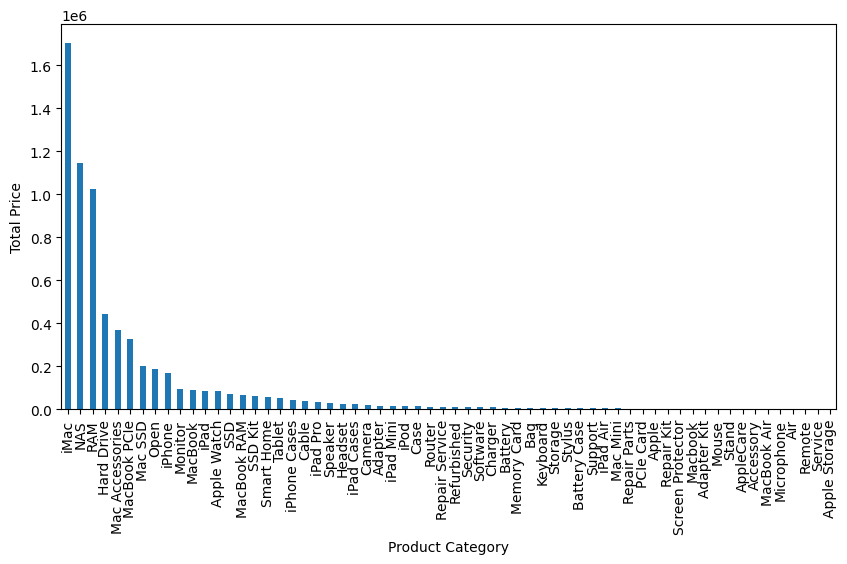

In [ ]:
product_category_df.groupby('category')['price'].sum().sort_values(ascending=False).plot(kind='bar',rot=90,figsize=(10,5),xlabel='Product Category',ylabel='Total Price')

####1.4.4.2.Discount per Category

In [ ]:
orderlines_merged = pd.merge(
    orderlines_qa,
    product_category_df[["sku", "category"]],
    on="sku",
    how="left"
)
# 2. Leere Kategorien (falls eine SKU in der Produkttabelle fehlte) mit "Unknown" füllen
orderlines_merged["category"] = orderlines_merged["category"].fillna("Unknown")

# 3. Umsatz pro Bestellzeile berechnen (Menge * Einzelpreis)
orderlines_merged["total_price"] = orderlines_merged["product_quantity"] * orderlines_merged["unit_price"]

# 4. Bestseller-Analyse: Umsatz und Menge pro Kategorie gruppieren und sortieren
category_performance = orderlines_merged.groupby("category").agg({
    "total_price": "sum",
    "product_quantity": "sum"
}).sort_values(by="total_price", ascending=False)

# 5. Anzeige der erfolgreichsten Kategorien
display(category_performance)

,total_price,product_quantity
category,,
iMac,30754584.63,11384
Mac Accessories,20737450.40,8506
iPhone,13471105.56,18920
RAM,10092958.99,19190
Hard Drive,5561267.31,28304
MacBook PCIe,4494867.63,1768
Unknown,3824603.37,11103
iPad,3394042.72,4790
Mac SSD,3376379.11,765


<Axes: title={'center': 'Echter Umsatz pro Produktkategorie (nur abgeschlossene Bestellungen)'}, xlabel='Kategorie', ylabel='Umsatz in €'>

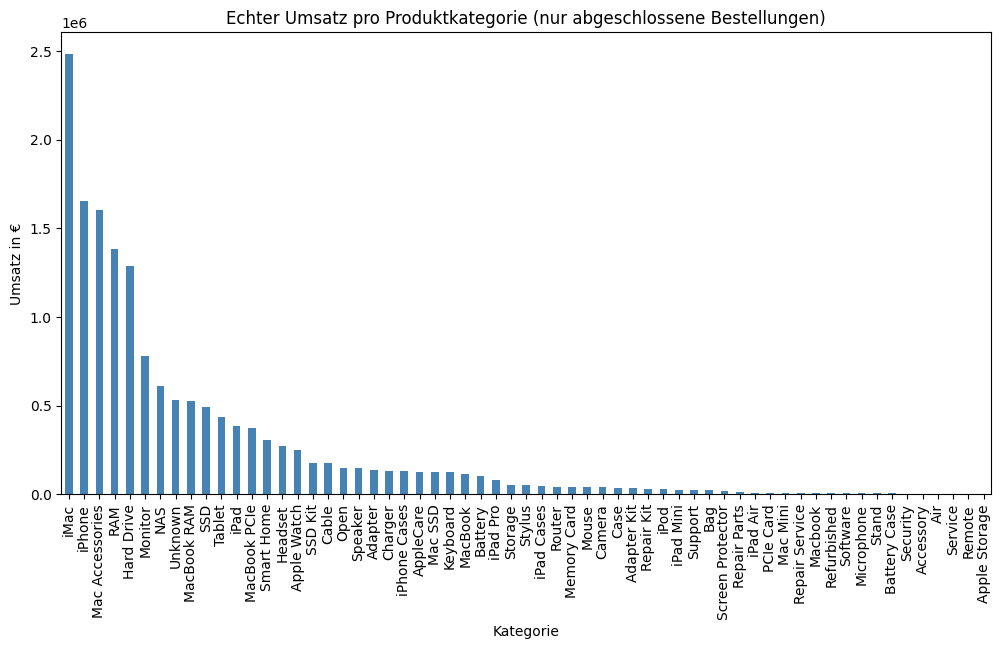

In [ ]:
# 1. Bestelldetails mit dem Bestellstatus (orders_qa) verknüpfen
final_sales = pd.merge(
    orderlines_merged,
    orders_qa[["order_id", "state", "created_date"]],
    left_on="id_order",
    right_on="order_id",
    how="inner"
)

# 2. Nur erfolgreich abgeschlossene Bestellungen filtern ("Completed")
completed_sales = final_sales.loc[final_sales["state"] == "Completed"].copy()

# 3. Den echten Umsatz pro Kategorie aggregieren und absteigend sortieren
real_category_revenue = completed_sales.groupby("category")["total_price"].sum().sort_values(ascending=False)

# 4. Das Ergebnis als vertikales Balkendiagramm visualisieren
real_category_revenue.plot.bar(
    figsize=(12, 6),
    title="Echter Umsatz pro Produktkategorie (nur abgeschlossene Bestellungen)",
    ylabel="Umsatz in €",
    xlabel="Kategorie",
    color="steelblue"
)

<Axes: title={'center': 'Echter Umsatz pro Einzel-Kategorie'}, xlabel='Kategorie', ylabel='Umsatz in €'>

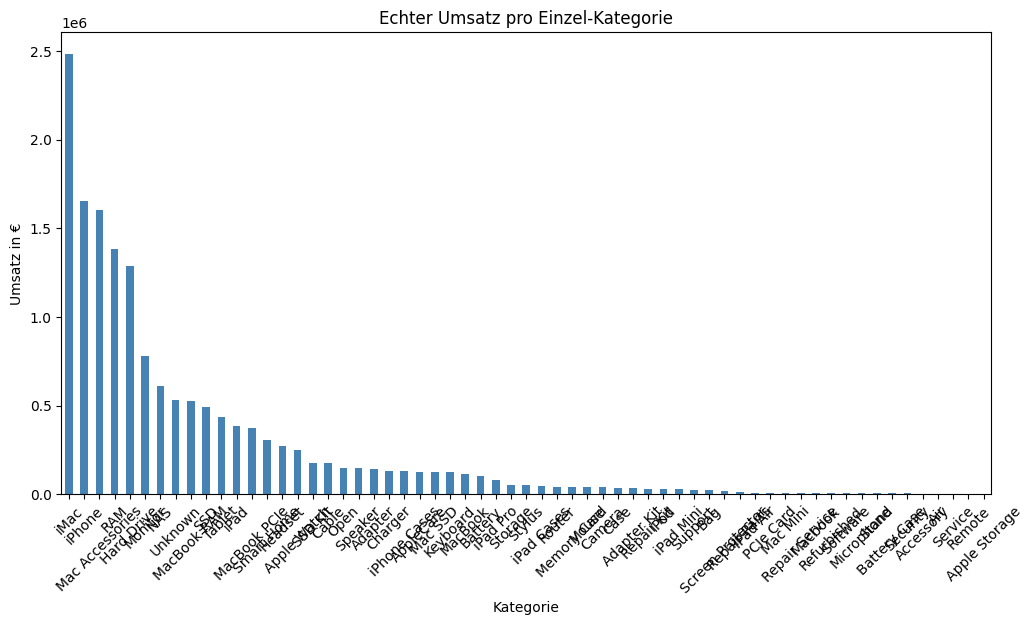

In [ ]:
# 1. Kommagetrennte Strings in echte Python-Listen umwandeln

completed_sales["category"] = completed_sales["category"].str.split(", ")

# 2. Zeilen "explodieren" lassen (1 Artikel mit 2 Kategorien wird zu 2 getrennten Zeilen)
exploded_sales = completed_sales.explode("category")

# 3. Echten Umsatz pro einzelner Kategorie berechnen
real_category_revenue = exploded_sales.groupby("category")["total_price"].sum().sort_values(ascending=False)

# 4. Aufgeräumtes Diagramm zeichnen
real_category_revenue.plot.bar(
    figsize=(12, 6),
    title="Echter Umsatz pro Einzel-Kategorie",
    ylabel="Umsatz in €",
    xlabel="Kategorie",
    color="steelblue",
    rot=45  # Dreht die Schrift leicht für bessere Lesbarkeit
)

In [ ]:
# 1. Sicherstellen, dass der Einzelpreis in orderlines eine Zahl ist
orderlines_qa["unit_price"] = pd.to_numeric(orderlines_qa["unit_price"], errors="coerce")

# 2. Bestelldetails (orderlines) mit den neuen Produktkategorien verknüpfen (Left Join)
orderlines_merged = pd.merge(
    orderlines_qa,
    product_category_df[["sku", "category"]],
    on="sku",
    how="left"
)

# 3. Leere Kategorien (falls eine SKU in der Produkttabelle fehlte) mit "Unknown" füllen
orderlines_merged["category"] = orderlines_merged["category"].fillna("Unknown")

# 4. Umsatz pro Bestellzeile berechnen (Menge * Einzelpreis)
orderlines_merged["total_price"] = orderlines_merged["product_quantity"] * orderlines_merged["unit_price"]

# 5. Bestseller-Analyse: Umsatz und Menge pro Kategorie gruppieren und sortieren
category_performance = orderlines_merged.groupby("category").agg({
    "total_price": "sum",
    "product_quantity": "sum"
}).sort_values(by="total_price", ascending=False)

# 6. Anzeige der erfolgreichsten Kategorien
display(category_performance)

,total_price,product_quantity
category,,
iMac,30754584.63,11384
Mac Accessories,20737450.40,8506
iPhone,13471105.56,18920
RAM,10092958.99,19190
Hard Drive,5561267.31,28304
MacBook PCIe,4494867.63,1768
Unknown,3824603.37,11103
iPad,3394042.72,4790
Mac SSD,3376379.11,765


In [ ]:
# 1. Sicherstellen, dass der Einzelpreis in orderlines eine Zahl ist
orderlines_qa["unit_price"] = pd.to_numeric(orderlines_qa["unit_price"], errors="coerce")

# 2. Bestelldetails (orderlines) mit den neuen Produktkategorien verknüpfen (Left Join)
orderlines_merged = pd.merge(
    orderlines_qa,
    product_category_df[["sku", "category"]],
    on="sku",
    how="left"
)

# 3. Leere Kategorien mit einem verständlichen deutschen Begriff füllen
orderlines_merged["category"] = orderlines_merged["category"].fillna("Ohne Kategorie")

# 4. Umsatz pro Bestellzeile berechnen (Menge * Einzelpreis)
orderlines_merged["total_price"] = orderlines_merged["product_quantity"] * orderlines_merged["unit_price"]

# 5. Umsatz und Menge pro Kategorie gruppieren und sortieren
category_performance = orderlines_merged.groupby("category").agg({
    "total_price": "sum",
    "product_quantity": "sum"
}).sort_values(by="total_price", ascending=False)

# --- AB HIER: OPTIMIERUNG FÜR MENSCHEN ---

# 6. Technische Spaltennamen in verständliches Deutsch übersetzen
category_performance = category_performance.rename(columns={
    "total_price": "Gesamtumsatz",
    "product_quantity": "Verkaufte Stückzahl"
})

# 7. Die Kategorienamen (den Index) großschreiben (z.B. "smartphone" -> "Smartphone")
category_performance.index = category_performance.index.str.title()

# 8. Zahlen lesbar formatieren (Tausendertrennzeichen und Euro-Zeichen)
lesbare_tabelle = category_performance.style.format({
    "Gesamtumsatz": "{:,.2f} €",
    "Verkaufte Stückzahl": "{:,.0f}"
})

# 9. Anzeige der fertigen, formatierten Tabelle
display(lesbare_tabelle)

,Gesamtumsatz,Verkaufte Stückzahl
category,,
Imac,"30,754,584.63 €","11,384"
Mac Accessories,"20,737,450.40 €","8,506"
Iphone,"13,471,105.56 €","18,920"
Ram,"10,092,958.99 €","19,190"
Hard Drive,"5,561,267.31 €","28,304"
Macbook Pcie,"4,494,867.63 €","1,768"
Ohne Kategorie,"3,824,603.37 €","11,103"
Ipad,"3,394,042.72 €","4,790"
Mac Ssd,"3,376,379.11 €",765


In [ ]:
# 1. Sicherstellen, dass der Einzelpreis in orderlines eine Zahl ist
orderlines_qa["unit_price"] = pd.to_numeric(orderlines_qa["unit_price"], errors="coerce")

# 2. Bestelldetails (orderlines) mit den neuen Produktkategorien verknüpfen (Left Join)
orderlines_merged = pd.merge(
    orderlines_qa,
    product_category_df[["sku", "category"]],
    on="sku",
    how="left"
)

# 3. Leere Kategorien mit einem verständlichen Begriff füllen
orderlines_merged["category"] = orderlines_merged["category"].fillna("Ohne Kategorie")

# 4. Umsatz pro Bestellzeile berechnen (Menge * Einzelpreis)
orderlines_merged["total_price"] = orderlines_merged["product_quantity"] * orderlines_merged["unit_price"]

# 5. Kommagetrennte Kategorien in echte Listen umwandeln und aufteilen (Explode)
# (Das astype(str) stellt sicher, dass Pandas den Text fehlerfrei splitten kann)
orderlines_merged["category"] = orderlines_merged["category"].astype(str).str.split(", ")
orderlines_exploded = orderlines_merged.explode("category")

# 6. Umsatz und Menge pro einzelner Kategorie gruppieren und sortieren
category_performance = orderlines_exploded.groupby("category").agg({
    "total_price": "sum",
    "product_quantity": "sum"
}).sort_values(by="total_price", ascending=False)

# 7. Technische Spaltennamen in verständliches Deutsch übersetzen
category_performance = category_performance.rename(columns={
    "total_price": "Gesamtumsatz",
    "product_quantity": "Verkaufte Stückzahl"
})

# 8. Die Kategorienamen großschreiben (z.B. "laptop" -> "Laptop")
category_performance.index = category_performance.index.str.title()

# 9. Zahlen lesbar formatieren (Tausendertrennzeichen und Euro-Zeichen)
lesbare_tabelle = category_performance.style.format({
    "Gesamtumsatz": "{:,.2f} €",
    "Verkaufte Stückzahl": "{:,.0f}"
})

# 10. Anzeige der fertigen, aufgeteilten und formatierten Tabelle
display(lesbare_tabelle)

,Gesamtumsatz,Verkaufte Stückzahl
category,,
Imac,"30,754,584.63 €","11,384"
Mac Accessories,"20,737,450.40 €","8,506"
Iphone,"13,471,105.56 €","18,920"
Ram,"10,092,958.99 €","19,190"
Hard Drive,"5,561,267.31 €","28,304"
Macbook Pcie,"4,494,867.63 €","1,768"
Ohne Kategorie,"3,824,603.37 €","11,103"
Ipad,"3,394,042.72 €","4,790"
Mac Ssd,"3,376,379.11 €",765


<Axes: title={'center': 'Gesamtumsatz pro Produktkategorie'}, xlabel='Kategorie', ylabel='Umsatz in €'>

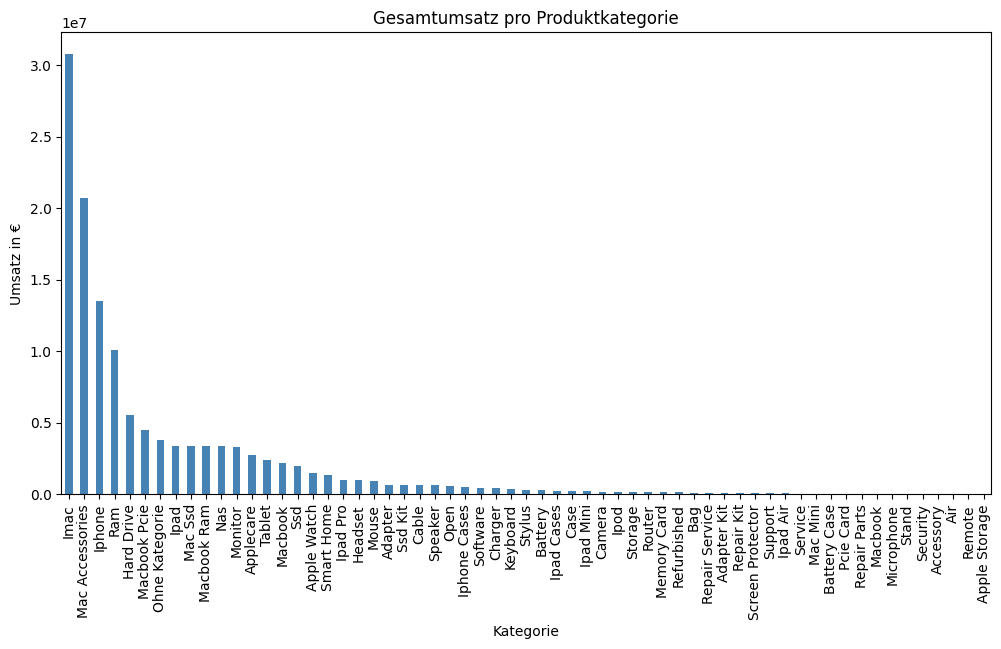

In [ ]:
# Ein vertikales Balkendiagramm für den Gesamtumsatz zeichnen
category_performance["Gesamtumsatz"].plot.bar(
    figsize=(12, 6),
    title="Gesamtumsatz pro Produktkategorie",
    ylabel="Umsatz in €",
    xlabel="Kategorie",
    color="steelblue",
    rot=90  # Dreht die Beschriftungen der X-Achse um 45 Grad
)

##1.4 Saving Files

In [ ]:
#from google.colab import files

#product_category_df.to_csv("products_categories.csv", index=False)
#files.download("categories.csv")